In [175]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

data3 = pd.read_csv("Best Copy of Energy Data for CS ML 2000-2022 - Sheet1.csv")
future_data3 = pd.read_csv("Best Copy of Energy Data for CS ML 2000-2022 - Sheet1.csv")
data3.head()

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_solar,elec_gen_wind,elec_gen_solar_thermal,elec_gen_geothermal,elec_gen_sol/geothermal,elec_gen_tide,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita
0,Australia,2000,2015828,806999,58896,0,3763,210841,1429894,175846,...,38,58,0,0,0,0,0,195.244,17.585955,45979.07657
1,Australia,2001,2018544,850415,59626,0,4531,212965,1281399,165416,...,44,210,0,0,0,0,0,206.484,17.690257,46314.62353
2,Australia,2002,2034808,788516,57157,0,5161,226713,1360752,125943,...,50,364,0,0,0,0,0,211.730,17.892464,47599.40793
3,Australia,2003,2015734,856586,58586,0,5521,219530,1480641,144840,...,58,703,1,0,1,0,0,207.548,17.665647,48509.66322
4,Australia,2004,2089200,859874,57996,0,5404,216460,1488010,151394,...,68,705,1,0,1,0,0,212.475,18.149135,50018.59045


In [176]:
data3["country"] = data3["country"].str.strip()
future_data3["country"] = future_data3["country"].str.strip()

In [177]:
data3["country_code"] = data3["country"].astype("category").cat.codes
future_data3["country_code"] = future_data3["country"].astype("category").cat.codes

In [178]:
data3["renew/sus_elec_gen"] = data3["elec_gen_solar"] + data3["elec_gen_wind"] + data3["elec_gen_hydro/tide"] + data3["elec_gen_sol/geothermal"]
future_data3["renew/sus_elec_gen"] = future_data3["elec_gen_solar"] + future_data3["elec_gen_wind"] + future_data3["elec_gen_hydro/tide"] + future_data3["elec_gen_sol/geothermal"]

In [179]:
data3["elec_gen_total"] = data3["renew/sus_elec_gen"] + data3["elec_gen_oil"] + data3["elec_gen_coal"] + data3["elec_gen_biofuels"] + data3["elec_gen_natural_gas"] + data3["elec_gen_nuclear"] + data3["elec_gen_other"] + data3["elec_gen_waste"]
future_data3["elec_gen_total"] = future_data3["renew/sus_elec_gen"] + future_data3["elec_gen_oil"] + future_data3["elec_gen_coal"] + future_data3["elec_gen_biofuels"] + future_data3["elec_gen_natural_gas"] + future_data3["elec_gen_nuclear"] + future_data3["elec_gen_other"] + future_data3["elec_gen_waste"]

In [180]:
data3["true_renew_share"] = data3["renew/sus_elec_gen"] / data3["elec_gen_total"]
future_data3["true_renew_share"] = future_data3["renew/sus_elec_gen"] / future_data3["elec_gen_total"]


In [181]:
data3["renew_share_change"] = data3.groupby("country_code")["true_renew_share"].diff()
future_data3["renew_share_change"] = future_data3.groupby("country_code")["true_renew_share"].diff()

In [182]:
future_data3

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_tide,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share,renew_share_change
0,Australia,2000,2015828,806999,58896,0,3763,210841,1429894,175846,...,0,0,195.244,17.585955,45979.07657,0,16816,210224,0.079991,NaN
1,Australia,2001,2018544,850415,59626,0,4531,212965,1281399,165416,...,0,0,206.484,17.690257,46314.62353,0,17187,224635,0.076511,-0.003480
2,Australia,2002,2034808,788516,57157,0,5161,226713,1360752,125943,...,0,0,211.730,17.892464,47599.40793,0,16468,227555,0.072369,-0.004141
3,Australia,2003,2015734,856586,58586,0,5521,219530,1480641,144840,...,0,0,207.548,17.665647,48509.66322,0,17252,220802,0.078133,0.005764
4,Australia,2004,2089200,859874,57996,0,5404,216460,1488010,151394,...,0,0,212.475,18.149135,50018.59045,0,17105,228434,0.074879,-0.003254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,United States,2018,13426291,29054726,1063803,9178130,1841813,4393036,33566263,701165,...,0,5272,4288.759,14.934503,59526.66570,38,696795,4455434,0.156392,-0.000398
893,United States,2019,11510279,31078534,1043274,9199964,1934725,4445624,33293509,644740,...,0,5074,4186.693,14.355887,60750.98986,38,724610,4391756,0.164993,0.008601
894,United States,2020,9280479,30104803,1033702,8979813,2180848,4108850,29400955,540438,...,0,4865,4109.389,12.830346,59194.66652,38,788187,4260036,0.185019,0.020026
895,United States,2021,10635146,30274618,912523,8853288,2455808,4383684,31968560,567856,...,0,4687,4169.876,13.681768,62680.25036,38,827308,4374671,0.189113,0.004094


In [183]:
data3

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_tide,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share,renew_share_change
0,Australia,2000,2015828,806999,58896,0,3763,210841,1429894,175846,...,0,0,195.244,17.585955,45979.07657,0,16816,210224,0.079991,NaN
1,Australia,2001,2018544,850415,59626,0,4531,212965,1281399,165416,...,0,0,206.484,17.690257,46314.62353,0,17187,224635,0.076511,-0.003480
2,Australia,2002,2034808,788516,57157,0,5161,226713,1360752,125943,...,0,0,211.730,17.892464,47599.40793,0,16468,227555,0.072369,-0.004141
3,Australia,2003,2015734,856586,58586,0,5521,219530,1480641,144840,...,0,0,207.548,17.665647,48509.66322,0,17252,220802,0.078133,0.005764
4,Australia,2004,2089200,859874,57996,0,5404,216460,1488010,151394,...,0,0,212.475,18.149135,50018.59045,0,17105,228434,0.074879,-0.003254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,United States,2018,13426291,29054726,1063803,9178130,1841813,4393036,33566263,701165,...,0,5272,4288.759,14.934503,59526.66570,38,696795,4455434,0.156392,-0.000398
893,United States,2019,11510279,31078534,1043274,9199964,1934725,4445624,33293509,644740,...,0,5074,4186.693,14.355887,60750.98986,38,724610,4391756,0.164993,0.008601
894,United States,2020,9280479,30104803,1033702,8979813,2180848,4108850,29400955,540438,...,0,4865,4109.389,12.830346,59194.66652,38,788187,4260036,0.185019,0.020026
895,United States,2021,10635146,30274618,912523,8853288,2455808,4383684,31968560,567856,...,0,4687,4169.876,13.681768,62680.25036,38,827308,4374671,0.189113,0.004094


In [184]:
data3["renew_share_next"] = data3.groupby("country_code")["true_renew_share"].shift(-1)

In [185]:
data3 = data3.dropna(subset=["renew_share_next"])
data3

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share,renew_share_change,renew_share_next
0,Australia,2000,2015828,806999,58896,0,3763,210841,1429894,175846,...,0,195.244,17.585955,45979.07657,0,16816,210224,0.079991,NaN,0.076511
1,Australia,2001,2018544,850415,59626,0,4531,212965,1281399,165416,...,0,206.484,17.690257,46314.62353,0,17187,224635,0.076511,-0.003480,0.072369
2,Australia,2002,2034808,788516,57157,0,5161,226713,1360752,125943,...,0,211.730,17.892464,47599.40793,0,16468,227555,0.072369,-0.004141,0.078133
3,Australia,2003,2015734,856586,58586,0,5521,219530,1480641,144840,...,0,207.548,17.665647,48509.66322,0,17252,220802,0.078133,0.005764,0.074879
4,Australia,2004,2089200,859874,57996,0,5404,216460,1488010,151394,...,0,212.475,18.149135,50018.59045,0,17105,228434,0.074879,-0.003254,0.072495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,United States,2017,13847655,26960229,1088504,9151214,1661988,4126342,33087374,712304,...,5443,4116.629,14.566783,58151.70214,38,672067,4286422,0.156790,0.020164,0.156392
892,United States,2018,13426291,29054726,1063803,9178130,1841813,4393036,33566263,701165,...,5272,4288.759,14.934503,59526.66570,38,696795,4455434,0.156392,-0.000398,0.164993
893,United States,2019,11510279,31078534,1043274,9199964,1934725,4445624,33293509,644740,...,5074,4186.693,14.355887,60750.98986,38,724610,4391756,0.164993,0.008601,0.185019
894,United States,2020,9280479,30104803,1033702,8979813,2180848,4108850,29400955,540438,...,4865,4109.389,12.830346,59194.66652,38,788187,4260036,0.185019,0.020026,0.189113


In [186]:
y3 = data3["renew_share_next"]
y3

0      0.076511
1      0.072369
2      0.078133
3      0.074879
4      0.072495
         ...   
891    0.156392
892    0.164993
893    0.185019
894    0.189113
895    0.205667
Name: renew_share_next, Length: 858, dtype: float64

In [187]:
X3 = data3.drop(columns=["renew_share_next", "country", "co2_emissions_total", "elec_gen_hydro", "elec_gen_tide", "elec_gen_geothermal",
                              "elec_gen_solar_thermal", "elec_gen_sol/geothermal", "elec_gen_hydro/tide", "elec_gen_solar", "elec_gen_wind", "elec_gen_total", "renew/sus_elec_gen",
                              "co2_emissions_coal", "co2_emissions_oil", "co2_emissions_natural_gas", "co2_emissions_other", "co2_emissions_elec_gen_incl_chp", 
                              "elec_gen_coal", "elec_gen_oil", "elec_gen_natural_gas", "elec_gen_biofuels", "elec_gen_waste", "elec_gen_nuclear", "elec_gen_other"])
X3

,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,tfc_oil,...,tfc_solar_wind,tfc_biofuels,tfc_electricity,tfc_heat,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,true_renew_share,renew_share_change
0,2000,2015828,806999,58896,0,3763,210841,1429894,175846,1453500,...,3417,181752,621896,0,195.244,17.585955,45979.07657,0,0.079991,NaN
1,2001,2018544,850415,59626,0,4531,212965,1281399,165416,1438847,...,3617,180038,649432,0,206.484,17.690257,46314.62353,0,0.076511,-0.003480
2,2002,2034808,788516,57157,0,5161,226713,1360752,125943,1417203,...,3670,190811,688021,0,211.730,17.892464,47599.40793,0,0.072369,-0.004141
3,2003,2015734,856586,58586,0,5521,219530,1480641,144840,1479100,...,2775,145331,665769,0,207.548,17.665647,48509.66322,0,0.078133,0.005764
4,2004,2089200,859874,57996,0,5404,216460,1488010,151394,1525625,...,2616,137087,681541,0,212.475,18.149135,50018.59045,0,0.074879,-0.003254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,2017,13847655,26960229,1088504,9151214,1661988,4126342,33087374,712304,31115924,...,88557,3237927,13522015,245406,4116.629,14.566783,58151.70214,38,0.156790,0.020164
892,2018,13426291,29054726,1063803,9178130,1841813,4393036,33566263,701165,31739161,...,148035,3503246,14043151,260320,4288.759,14.934503,59526.66570,38,0.156392,-0.000398
893,2019,11510279,31078534,1043274,9199964,1934725,4445624,33293509,644740,31622507,...,127018,3590849,13787827,252619,4186.693,14.355887,60750.98986,38,0.164993,0.008601
894,2020,9280479,30104803,1033702,8979813,2180848,4108850,29400955,540438,27963136,...,128891,3294752,13600044,249865,4109.389,12.830346,59194.66652,38,0.185019,0.020026


In [188]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X3_columns = X3.columns

train = data3[data3["year"] <= 2018]
test = data3[data3["year"] > 2018]

X3_train = train[X3_columns]
y3_train = train["renew_share_next"]

X3_test = test[X3_columns]
y3_test = test["renew_share_next"]

RF_model3 = RandomForestRegressor(n_estimators=200, random_state=42)
RF_model3.fit(X3_train, y3_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [189]:
X3_train

,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,tfc_oil,...,tfc_solar_wind,tfc_biofuels,tfc_electricity,tfc_heat,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,true_renew_share,renew_share_change
0,2000,2015828,806999,58896,0,3763,210841,1429894,175846,1453500,...,3417,181752,621896,0,195.244,17.585955,45979.07657,0,0.079991,NaN
1,2001,2018544,850415,59626,0,4531,212965,1281399,165416,1438847,...,3617,180038,649432,0,206.484,17.690257,46314.62353,0,0.076511,-0.003480
2,2002,2034808,788516,57157,0,5161,226713,1360752,125943,1417203,...,3670,190811,688021,0,211.730,17.892464,47599.40793,0,0.072369,-0.004141
3,2003,2015734,856586,58586,0,5521,219530,1480641,144840,1479100,...,2775,145331,665769,0,207.548,17.665647,48509.66322,0,0.078133,0.005764
4,2004,2089200,859874,57996,0,5404,216460,1488010,151394,1525625,...,2616,137087,681541,0,212.475,18.149135,50018.59045,0,0.074879,-0.003254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,2014,18072073,26276307,941302,9060916,1236979,4292757,32367234,929619,30246807,...,103741,3315329,13640234,234204,4138.262,15.790183,55394.45104,38,0.117477,0.002735
889,2015,15660181,27067980,903664,9057687,1312775,4183390,33056355,817007,30883847,...,107120,3228030,13611009,228511,4128.507,15.300856,56572.91890,38,0.120098,0.002621
890,2016,14300841,27334911,970812,9162741,1491265,4152602,32837869,732802,31040556,...,94308,3263132,13730187,277588,4153.733,14.905542,57151.47084,38,0.136626,0.016528
891,2017,13847655,26960229,1088504,9151214,1661988,4126342,33087374,712304,31115924,...,88557,3237927,13522015,245406,4116.629,14.566783,58151.70214,38,0.156790,0.020164


In [190]:
y3_train

0      0.076511
1      0.072369
2      0.078133
3      0.074879
4      0.072495
         ...   
888    0.120098
889    0.136626
890    0.156790
891    0.156392
892    0.164993
Name: renew_share_next, Length: 741, dtype: float64

In [191]:
y3_rf_train_pred = RF_model3.predict(X3_train)
y3_rf_test_pred = RF_model3.predict(X3_test)

In [192]:
from sklearn.metrics import mean_squared_error, r2_score

rf3_train_mse = mean_squared_error(y3_train, y3_rf_train_pred)
rf3_train_r2 = r2_score(y3_train, y3_rf_train_pred)

rf3_test_mse = mean_squared_error(y3_test, y3_rf_test_pred)
rf3_test_r2 = r2_score(y3_test, y3_rf_test_pred)


In [193]:
rf3_results = pd.DataFrame(["Random Forest Regressor", rf3_train_mse, rf3_train_r2, rf3_test_mse, rf3_test_r2]).transpose()
rf3_results.columns = ["Method", "Training MSE", "Training R2", "Testing MSE", "Testing R2"]
rf3_results

,Method,Training MSE,Training R2,Testing MSE,Testing R2
0,Random Forest Regressor,0.000198,0.996688,0.00166,0.969238


In [194]:
import pandas as pd

importance3 = RF_model3.feature_importances_

feature_importance3 = pd.Series(importance3, index=X3.columns)
print(feature_importance3.sort_values(ascending=False))

true_renew_share            0.972634
tfc_solar_wind              0.003594
renew_share_change          0.003498
country_code                0.002696
tfc_heat                    0.002557
year                        0.001755
tfc_coal                    0.001627
tes_natural_gas             0.001467
gdp_per_capita              0.001316
tes_coal                    0.001269
tfc_natural_gas             0.001131
co2_emissions_per_capita    0.000995
tes_solar_wind_otr          0.000994
tfc_biofuels                0.000847
tfc_electricity             0.000664
tes_biofuels                0.000611
tes_oil                     0.000597
tes_hydro                   0.000541
tfc_oil                     0.000482
elec_consumption_total      0.000477
tes_nucelar                 0.000250
dtype: float64


In [195]:
future_data3 = future_data3[future_data3["year"] == 2022].copy()

X3_future = future_data3[X3_columns]
X3_future

future_data3["pred_2023"] = RF_model3.predict(X3_future)

In [196]:
future_data3

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share,renew_share_change,pred_2023
22,Australia,2022,1567046,1503810,58669,0,251098,200757,1802372,113070,...,0,258.195,13.641457,61200.458900,0,80803,271528,0.297586,0.043585,0.329460
45,Austria,2022,103900,288460,124650,0,48905,271087,451260,15620,...,14,74.655,6.260908,47332.424040,1,50163,69187,0.725035,-0.011263,0.722195
68,Belgium,2022,114320,541168,975,478681,70539,168675,779594,45622,...,418,85.064,6.890466,44486.743860,2,20875,95943,0.217577,0.028799,0.228070
91,Brazil,2022,585975,1171980,1537608,158825,444205,3968936,4697278,337629,...,474,586.284,1.970545,9032.083777,3,538870,677368,0.795535,0.106842,0.787204
114,Canada,2022,335473,4977785,1431669,951698,164156,565136,4113893,83247,...,300,580.421,13.439031,45677.686580,4,443008,658578,0.672674,0.016230,0.650899
137,China,2022,96662534,12449865,4688347,4557548,6149038,5304558,28481573,22002949,...,0,8631.405,7.520268,11830.598370,5,2544417,8950638,0.284272,0.013973,0.313197
160,Czechia,2022,562516,265512,7536,339285,12601,205133,396168,81669,...,132,67.908,8.430156,20627.348650,6,6350,84845,0.074842,-0.001254,0.075100
183,Denmark,2022,45107,60863,53,0,79922,209172,236015,4460,...,0,34.517,4.539657,59108.744940,7,21238,35120,0.604727,0.078854,0.624838
206,Egypt,2022,76047,2197587,55648,0,38913,141008,1750953,69127,...,0,166.444,2.040379,4029.782955,8,26195,209396,0.125098,0.003477,0.135101
229,Estonia,2022,123123,12268,82,0,4550,52106,5220,2478,...,0,8.720,7.446272,21023.299490,9,1287,8934,0.144056,-0.009950,0.158841


In [197]:
future_2023 = future_data3.copy()

future_2023["year"] = 2023

future_2023["true_renew_share"] = future_data3["pred_2023"]
future_2023["renew_share_change"] = future_2023["true_renew_share"] - future_data3["true_renew_share"]

X_future_2023 = future_2023[X3_columns]

future_2023["pred_2024"] = RF_model3.predict(X_future_2023)



In [198]:
future_data3[["country", "true_renew_share", "pred_2023"]].head()

,country,true_renew_share,pred_2023
22,Australia,0.297586,0.329460
45,Austria,0.725035,0.722195
68,Belgium,0.217577,0.228070
91,Brazil,0.795535,0.787204
114,Canada,0.672674,0.650899


In [199]:
future_2023[["country", "true_renew_share", "pred_2024"]].head()

,country,true_renew_share,pred_2024
22,Australia,0.329460,0.344150
45,Austria,0.722195,0.720253
68,Belgium,0.228070,0.251714
91,Brazil,0.787204,0.805614
114,Canada,0.650899,0.652374


In [200]:
future_2024 = future_2023.copy()

future_2024["year"] = 2024

future_2024["true_renew_share"] = future_2023["pred_2024"]
future_2024["renew_share_change"] = future_2024["true_renew_share"] - future_2023["true_renew_share"]

X_future_2024 = future_2024[X3_columns]

future_2024["pred_2025"] = RF_model3.predict(X_future_2024)

In [201]:
future_2025 = future_2024.copy()

future_2025["year"] = 2025

future_2025["true_renew_share"] = future_2024["pred_2025"]
future_2025["renew_share_change"] = future_2025["true_renew_share"] - future_2024["true_renew_share"]

X_future_2025 = future_2025[X3_columns]

future_2025["pred_2026"] = RF_model3.predict(X_future_2025)

In [202]:
future_2026 = future_2025.copy()

future_2026["year"] = 2026

future_2026["true_renew_share"] = future_2025["pred_2026"]
future_2026["renew_share_change"] = future_2026["true_renew_share"] - future_2025["true_renew_share"]

X_future_2026 = future_2026[X3_columns]

future_2026["pred_2027"] = RF_model3.predict(X_future_2026)

In [203]:
future_2027 = future_2026.copy()

future_2027["year"] = 2027

future_2027["true_renew_share"] = future_2026["pred_2027"]
future_2027["renew_share_change"] = future_2027["true_renew_share"] - future_2026["true_renew_share"]

X_future_2027 = future_2027[X3_columns]

future_2027["pred_2028"] = RF_model3.predict(X_future_2027)

In [204]:
future_2028 = future_2027.copy()

future_2028["year"] = 2028

future_2028["true_renew_share"] = future_2027["pred_2028"]
future_2028["renew_share_change"] = future_2028["true_renew_share"] - future_2027["true_renew_share"]

X_future_2028 = future_2028[X3_columns]

future_2028["pred_2029"] = RF_model3.predict(X_future_2028)

In [205]:
future_2029 = future_2028.copy()

future_2029["year"] = 2029

future_2029["true_renew_share"] = future_2028["pred_2029"]
future_2029["renew_share_change"] = future_2029["true_renew_share"] - future_2028["true_renew_share"]

X_future_2029 = future_2029[X3_columns]

future_2029["pred_2030"] = RF_model3.predict(X_future_2029)

In [206]:
future_2030 = future_2029.copy()

future_2030["year"] = 2030

future_2030["true_renew_share"] = future_2029["pred_2030"]
future_2030["renew_share_change"] = future_2030["true_renew_share"] - future_2029["true_renew_share"]

X_future_2030 = future_2030[X3_columns]

future_2030["pred_2031"] = RF_model3.predict(X_future_2030)

In [207]:
future_2031 = future_2030.copy()

future_2031["year"] = 2031

future_2031["true_renew_share"] = future_2030["pred_2031"]
future_2031["renew_share_change"] = future_2031["true_renew_share"] - future_2030["true_renew_share"]

X_future_2031 = future_2031[X3_columns]

future_2031["pred_2032"] = RF_model3.predict(X_future_2031)

In [208]:
future_2032 = future_2031.copy()

future_2032["year"] = 2032

future_2032["true_renew_share"] = future_2031["pred_2032"]
future_2032["renew_share_change"] = future_2032["true_renew_share"] - future_2031["true_renew_share"]

X_future_2032 = future_2032[X3_columns]

future_2032["pred_2033"] = RF_model3.predict(X_future_2032)

In [209]:
future_2033 = future_2032.copy()

future_2033["year"] = 2033

future_2033["true_renew_share"] = future_2032["pred_2033"]
future_2033["renew_share_change"] = future_2033["true_renew_share"] - future_2032["true_renew_share"]

X_future_2033 = future_2033[X3_columns]

future_2033["pred_2034"] = RF_model3.predict(X_future_2033)

In [210]:
future_2034 = future_2033.copy()

future_2034["year"] = 2034

future_2034["true_renew_share"] = future_2033["pred_2034"]
future_2034["renew_share_change"] = future_2034["true_renew_share"] - future_2033["true_renew_share"]

X_future_2034 = future_2034[X3_columns]

future_2034["pred_2035"] = RF_model3.predict(X_future_2034)

In [211]:
future_2034[["country", "true_renew_share", "pred_2035"]].head()

,country,true_renew_share,pred_2035
22,Australia,0.358641,0.362926
45,Austria,0.720152,0.720152
68,Belgium,0.463828,0.463936
91,Brazil,0.804585,0.802520
114,Canada,0.649660,0.649964


In [212]:
future_2023[["country", "true_renew_share", "pred_2024"]].head()

,country,true_renew_share,pred_2024
22,Australia,0.329460,0.344150
45,Austria,0.722195,0.720253
68,Belgium,0.228070,0.251714
91,Brazil,0.787204,0.805614
114,Canada,0.650899,0.652374


In [216]:
country_name39 = "Estonia"

country_row = future_data3[future_data3["country"] == country_name39]

years = [2022]
country_row

,country,year,tes_coal,tes_natural_gas,tes_hydro,tes_nucelar,tes_solar_wind_otr,tes_biofuels,tes_oil,tfc_coal,...,elec_gen_other,elec_consumption_total,co2_emissions_per_capita,gdp_per_capita,country_code,renew/sus_elec_gen,elec_gen_total,true_renew_share,renew_share_change,pred_2023
229,Estonia,2022,123123,12268,82,0,4550,52106,5220,2478,...,0,8.72,7.446272,21023.29949,9,1287,8934,0.144056,-0.00995,0.158841


In [217]:
shares.append(country_row["pred_2023"].values[0])
years.append(2023)

shares.append(future_2023[future_2023["country"] == country_name39]["pred_2024"].values[0])
years.append(2024)

shares.append(future_2024[future_2024["country"] == country_name39]["pred_2025"].values[0])
years.append(2025)

shares.append(future_2025[future_2025["country"] == country_name39]["pred_2026"].values[0])
years.append(2026)

shares.append(future_2026[future_2026["country"] == country_name39]["pred_2027"].values[0])
years.append(2027)

shares.append(future_2027[future_2027["country"] == country_name39]["pred_2028"].values[0])
years.append(2028)

shares.append(future_2028[future_2028["country"] == country_name39]["pred_2029"].values[0])
years.append(2029)

shares.append(future_2029[future_2029["country"] == country_name39]["pred_2030"].values[0])
years.append(2030)

shares.append(future_2030[future_2030["country"] == country_name39]["pred_2031"].values[0])
years.append(2031)

shares.append(future_2031[future_2031["country"] == country_name39]["pred_2032"].values[0])
years.append(2032)

shares.append(future_2032[future_2032["country"] == country_name39]["pred_2033"].values[0])
years.append(2033)

shares.append(future_2033[future_2033["country"] == country_name39]["pred_2034"].values[0])
years.append(2034)

shares.append(future_2034[future_2034["country"] == country_name39]["pred_2035"].values[0])
years.append(2035)

In [218]:
shares

[np.float64(0.2056673077718769),
 np.float64(0.23398151292500194),
 np.float64(0.2472206673763504),
 np.float64(0.25454564584435047),
 np.float64(0.26882051703274096),
 np.float64(0.2843450409617918),
 np.float64(0.3191716485255717),
 np.float64(0.35721366233039625),
 np.float64(0.3711337939606906),
 np.float64(0.3785597514137526),
 np.float64(0.41601107890586775),
 np.float64(0.4579304663509864),
 np.float64(0.47612273497849567),
 np.float64(0.4796491794323227),
 np.float64(0.15884062365304785),
 np.float64(0.18531514582994188),
 np.float64(0.1906210868481788),
 np.float64(0.20778064706135083),
 np.float64(0.24095647385679939),
 np.float64(0.2589392359538183),
 np.float64(0.272971933781173),
 np.float64(0.28145299120772194),
 np.float64(0.2943882630967802),
 np.float64(0.3141835239510419),
 np.float64(0.33093385572123724),
 np.float64(0.35040091814593166),
 np.float64(0.40419279824179166)]

ValueError: x and y must have same first dimension, but have shapes (14,) and (27,)

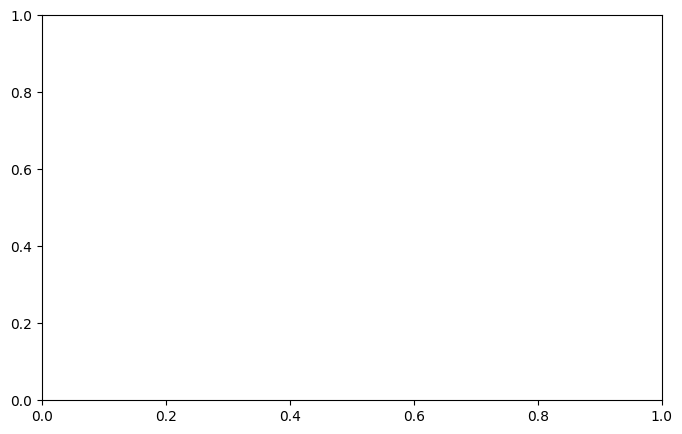

In [219]:
plt.figure(figsize=(8,5))

plt.plot(years, shares, marker="o")

plt.xlabel("Year")
plt.ylabel("Renewable Electricity Share")
plt.title(f"Predicted Renewable Share Path: {country_name39}")

plt.grid(True)

plt.show()

In [ ]:
data3["year"].max()

np.int64(2021)

In [ ]:
print(data3["country"].unique())

['Australia ' 'Austria ' 'Belgium' 'Brazil' 'Canada' 'China' 'Czechia'
 'Denmark' 'Egypt' 'Estonia' 'Finland' 'France' 'Germany' 'Greece'
 'Hungary' 'India' 'Indonesia' 'Ireland' 'Italy' 'Japan' 'Korea' 'Latvia'
 'Lithuania' 'Luxembourg' 'Mexico' 'Morocco' 'Netherlands' 'New Zealand'
 'Norway' 'Poland' 'Portugal' 'Russia' 'Slovakia' 'Spain' 'Sweden'
 'Switzerland' 'Turkey' 'United Kingdom' 'United States']


In [ ]:
recent_data = data3[data3["year"] == data3["year"].max()].copy()
forecast_results = []

current_data = recent_data.copy()

for year in range(2023, 2036):

    X_future = current_data[X3_columns]

    predictions = RF_model3.predict(X_future)

    current_data["predictions_share"] = predictions

    temp = current_data[["country"]].copy()
    temp["year"] = year
    temp["renew_share"] = predictions

    forecast_results.append(temp)

    current_data["renew_share_change"] = predictions - current_data["true_renew_share"]
    current_data["true_renew_share"] = predictions
    current_data["year"] = year

In [ ]:
forecast_df = pd.concat(forecast_results)
forecast_df

,country,year,renew_share
21,Australia,2023,0.269829
44,Austria,2023,0.718956
67,Belgium,2023,0.187059
90,Brazil,2023,0.702061
113,Canada,2023,0.647146
...,...,...,...
803,Sweden,2035,0.497166
826,Switzerland,2035,0.594883
849,Turkey,2035,0.448572
872,United Kingdom,2035,0.462414


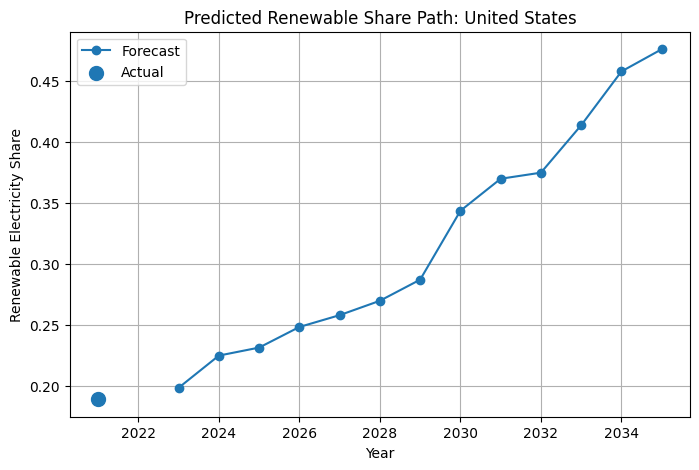

In [ ]:
country_1 = "United States"

country_path = forecast_df[forecast_df["country"] == country_1]

plt.figure(figsize=(8,5))

plt.plot(country_path["year"], country_path["renew_share"], marker="o", label="Forecast")

country_data = data3[data3["country"] == country_1]

latest_year = country_data["year"].max()

start_value = country_data[country_data["year"] == latest_year]["true_renew_share"].values[0]

plt.scatter(latest_year, start_value, s=100, label="Actual")

plt.xlabel("Year")
plt.ylabel("Renewable Electricity Share")
plt.title(f"Predicted Renewable Share Path: {country_1}")

plt.legend()
plt.grid(True)

plt.show()